In [ ]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [ ]:
# Import the 'drive' module from 'google.colab' which allows Colab to access Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# We define the file path to the CSV dataset stored in Google Drive
file_path = '/content/drive/MyDrive/datasets/cafe.csv'

# We read the CSV file from the specified path into a pandas DataFrame called 'nfl_data'
cafe_data = pd.read_csv(file_path)

In [ ]:
# check the structure of the dataset
cafe_data.info()

# From the info() function, we have missing values and wrong data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
# check the first five rows
cafe_data.head()

# we have issues in column values, as there are Error, Unknown

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
# check data statistics
cafe_data.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [ ]:
# check missing values
cafe_data.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [ ]:
# check 'Item' unique values
cafe_data['Item'].unique()

# we have UNKNOWN, nan, ERROR, and valid values

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [ ]:
# standardize fake missing values (UNKNOWN, ERROR,) in the 'Item' colummn to 'nan'
cafe_data['Item'] = cafe_data['Item'].replace(['UNKNOWN', 'ERROR'], np.nan)

In [ ]:
# check if the standarizing process functioned
cafe_data['Item'].unique()

# it did work

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', nan, 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [ ]:
# check the percentage of missing values
cafe_data['Item'].isna().mean() * 100

# 9.69% of the Item column is missing.

np.float64(9.69)

In [ ]:
# drop 'NaN' from the 'Item' column
cafe_data = cafe_data.dropna(subset=['Item'])

In [ ]:
cafe_data['Item'].isna().sum()

# the missing nan were droped

np.int64(0)

In [ ]:
# check the values of Item column
cafe_data['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [ ]:
# convert values of Items into category for better visualization and analysis
cafe_data['Item'] = cafe_data['Item'].astype('category')
print(cafe_data['Item'].dtype)

category


In [ ]:
# check the unique values of 'Quantity' column
cafe_data['Quantity'].unique()

# we have numers as strings, fake missing values, and missing values'nan'

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [ ]:
# standarize the fake missing values
cafe_data['Quantity']= cafe_data['Quantity'].replace(['ERROR', 'UNKNOWN'], np.nan)

In [ ]:
# check if the standarizing process functioned
cafe_data['Quantity'].unique()

# it did work

array(['2', '4', '5', '3', '1', nan], dtype=object)

In [ ]:
# convert 'Quantity' into numeric
cafe_data['Quantity'] = pd.to_numeric(
    cafe_data['Quantity'], errors='coerce')

In [ ]:
# check if 'Quantity' data type column is converted into numeric
cafe_data['Quantity'].dtype

# it is float64 not int64 because pandas cannot store NaN in integer columns.
# we need to address 'nan' values

dtype('float64')

In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Quantity'].isna().sum())
print(cafe_data['Quantity'].isna().mean()*100)

# The percentage is low and safe to drop these rows

420
4.650647768796368


In [ ]:
# drop missing values in the 'Quantity' column
cafe_data = cafe_data.dropna(subset=['Quantity'])

# check unique values
print(cafe_data['Quantity'].unique())

# check datatype
print(cafe_data['Quantity'].dtype)

[2. 4. 5. 3. 1.]
float64


In [ ]:
# convert the data type 'float64' into 'int64'
cafe_data['Quantity'] = cafe_data['Quantity'].astype(int)

# check the data type
print(cafe_data['Quantity'].dtype)

int64


In [ ]:
# check the unique values of 'price' column
cafe_data['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [ ]:
# standarize the fake missing values

cafe_data['Price Per Unit']= cafe_data['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)

# check if the standarizing process functioned
cafe_data['Price Per Unit'].unique()

# it did work

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan], dtype=object)

In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Price Per Unit'].isna().sum())
print(cafe_data['Price Per Unit'].isna().mean()*100)

# The percentage is low and safe to drop these rows

464
5.388456625246777


In [ ]:
# drop missing values in the 'Quantity' column
cafe_data = cafe_data.dropna(subset=['Price Per Unit'])

# check unique values
print(cafe_data['Price Per Unit'].unique())

# check datatype
print(cafe_data['Price Per Unit'].dtype)

['2.0' '3.0' '1.0' '5.0' '4.0' '1.5']
object


In [ ]:
# convert data types of 'Price Per Unit' column into float64
cafe_data['Price Per Unit'] = cafe_data['Price Per Unit'].astype(np.float64)
print(cafe_data['Price Per Unit'].dtype)

float64


In [ ]:
# check the unique values of 'Total spent'
cafe_data['Total Spent'].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '16.0', '25.0', '8.0',
       '5.0', '15.0', '6.0', nan, 'UNKNOWN', '2.0', '9.0', '1.0', '3.0',
       '7.5', '1.5', '4.5'], dtype=object)

In [ ]:
# standarize the fake missing values
cafe_data['Total Spent'] = cafe_data['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)

# check the unique values
print(cafe_data['Total Spent'].unique())

['4.0' '12.0' nan '10.0' '20.0' '16.0' '25.0' '8.0' '5.0' '15.0' '6.0'
 '2.0' '9.0' '1.0' '3.0' '7.5' '1.5' '4.5']


In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Total Spent'].isna().mean()*100)
print(cafe_data['Total Spent'].isna().sum())

5.093899594942924
415


In [ ]:
# check if the missing values in the 'Total Spent' variable have relationships with different columns
cafe_data.head(100)

# 'Total Spent' is the result of 'Quantity * Price Per Unit'
# We need to use imputation-based rule instead of dropping the missing values

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
122,TXN_5179020,Cake,2,3.0,6.0,NaN,Takeaway,2023-06-18
123,TXN_6258471,Coffee,5,2.0,10.0,Digital Wallet,In-store,2023-09-23
124,TXN_7945375,Juice,3,3.0,9.0,NaN,NaN,2023-01-14
125,TXN_4685453,Tea,4,1.5,6.0,Cash,In-store,2023-09-14


In [ ]:
# we apply imputation-based rule for filling the nan values using 'Quantity' * 'Price Per Unit'
# create a boolean mask to identify rows where 'Total Spent' is missing (NaN)
mask = cafe_data['Total Spent'].isna()

# Fill missing values in 'Total Spent' by calculating Quantity × Price Per Unit for valid rows
cafe_data.loc[mask, 'Total Spent'] = (
    cafe_data['Quantity'] * cafe_data['Price Per Unit']
)

# check missing values to make sure the code functioned
cafe_data['Total Spent'].isna().sum()

np.int64(0)

In [ ]:
# convert the data type of 'Total Spent' into float64
cafe_data['Total Spent']=cafe_data['Total Spent'].astype(np.float64)

# check data type
cafe_data['Total Spent'].dtype


dtype('float64')

In [ ]:
# check the unique values of the 'Payment Method' column
cafe_data['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', nan, 'ERROR'],
      dtype=object)

In [ ]:
# standarize the missing values
cafe_data['Payment Method'] = cafe_data['Payment Method'].replace(['UNKNOWN', 'ERROR'], np.nan)

# check if the standrization functioned
cafe_data['Payment Method'].unique()

array(['Credit Card', 'Cash', nan, 'Digital Wallet'], dtype=object)

In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Payment Method'].isna().sum())
print(cafe_data['Payment Method'].isna().mean()*100)

# We have many missing values

2584
31.71719651405425


In [ ]:
# Fill missing values in 'Payment Method' with 'Unknown' because ~31.7% of values are missing,
# and dropping them would remove too much data and bias the analysis
# fill the missing nan with 'Unknown'
cafe_data['Payment Method'] = cafe_data['Payment Method'].fillna('Unknown')

# check if the filling strategy functioned
cafe_data['Payment Method'].unique()

array(['Credit Card', 'Cash', 'Unknown', 'Digital Wallet'], dtype=object)

In [ ]:
# check data type
cafe_data['Payment Method'].dtype

# the data type is object. it is better to convert into category for better memory and visualization

dtype('O')

In [ ]:
# convert data type into category
cafe_data['Payment Method'] = cafe_data['Payment Method'].astype('category')

# check data type again
print(cafe_data['Payment Method'].dtype)

category


In [ ]:
# check the unique values of the 'Payment Method' column
cafe_data['Location'].unique()

array(['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR'], dtype=object)

In [ ]:
# standarize the missing values
cafe_data['Location'] = cafe_data['Location'].replace(['UNKNOWN', 'ERROR'], np.nan)

# check if the standrization functioned
cafe_data['Location'].unique()

array(['Takeaway', 'In-store', nan], dtype=object)

In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Location'].isna().sum())
print(cafe_data['Location'].isna().mean()*100)

# We have many missing values

3233
39.68331901313367


In [ ]:
# Fill missing values in 'Payment Method' with 'Unknown' because ~39.7% of values are missing,
# and dropping them would remove too much data and bias the analysis
# fill the missing nan with 'Unknown'
cafe_data['Location'] = cafe_data['Location'].fillna('Unknown')

# check if the filling strategy functioned
cafe_data['Location'].unique()

array(['Takeaway', 'In-store', 'Unknown'], dtype=object)

In [ ]:
# check data type
cafe_data['Location'].dtype

# the data type is object. it is better to convert into category for better memory and visualization

dtype('O')

In [ ]:
# convert data type into category
cafe_data['Location'] = cafe_data['Location'].astype('category')

# check data type again
print(cafe_data['Location'].dtype)

category


In [ ]:
cafe_data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
# check the unique values of the 'Payment Method' column
cafe_data['Transaction Date'].unique()

array(['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27',
       '2023-06-11', '2023-03-31', '2023-10-28', '2023-12-31',
       '2023-11-07', 'ERROR', '2023-05-03', '2023-06-01', '2023-11-15',
       '2023-06-10', '2023-02-24', '2023-03-25', '2023-01-15',
       '2023-03-30', '2023-12-01', '2023-09-18', '2023-06-03',
       '2023-12-13', '2023-04-20', '2023-04-10', '2023-03-11',
       '2023-08-15', '2023-10-09', '2023-05-28', '2023-04-29',
       '2023-06-08', '2023-06-29', '2023-04-17', '2023-12-22',
       '2023-01-10', '2023-10-02', '2023-02-23', '2023-03-22',
       '2023-11-03', '2023-03-02', '2023-06-26', '2023-05-02',
       '2023-09-05', '2023-01-08', '2023-11-25', '2023-12-05',
       '2023-10-07', '2023-09-30', '2023-05-27', '2023-10-03',
       '2023-01-31', '2023-06-19', '2023-12-14', '2023-07-16',
       '2023-02-22', nan, '2023-06-02', '2023-06-15', '2023-12-09',
       '2023-04-18', '2023-04-30', '2023-04-02', '2023-08-16',
       '2023-09-10', '2023-03-07', '2023-

In [ ]:
# standarize the missing values
cafe_data['Transaction Date'] = cafe_data['Transaction Date'].replace(['UNKNOWN'], np.nan)

# check if the standrization functioned
cafe_data['Transaction Date'].unique()

array(['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27',
       '2023-06-11', '2023-03-31', '2023-10-28', '2023-12-31',
       '2023-11-07', 'ERROR', '2023-05-03', '2023-06-01', '2023-11-15',
       '2023-06-10', '2023-02-24', '2023-03-25', '2023-01-15',
       '2023-03-30', '2023-12-01', '2023-09-18', '2023-06-03',
       '2023-12-13', '2023-04-20', '2023-04-10', '2023-03-11',
       '2023-08-15', '2023-10-09', '2023-05-28', '2023-04-29',
       '2023-06-08', '2023-06-29', '2023-04-17', '2023-12-22',
       '2023-01-10', '2023-10-02', '2023-02-23', '2023-03-22',
       '2023-11-03', '2023-03-02', '2023-06-26', '2023-05-02',
       '2023-09-05', '2023-01-08', '2023-11-25', '2023-12-05',
       '2023-10-07', '2023-09-30', '2023-05-27', '2023-10-03',
       '2023-01-31', '2023-06-19', '2023-12-14', '2023-07-16',
       '2023-02-22', nan, '2023-06-02', '2023-06-15', '2023-12-09',
       '2023-04-18', '2023-04-30', '2023-04-02', '2023-08-16',
       '2023-09-10', '2023-03-07', '2023-

In [ ]:
# check the number and the percentage of missing values
print(cafe_data['Transaction Date'].isna().sum())
print(cafe_data['Transaction Date'].isna().mean()*100)

# We have very few missing values

255
3.129986498097459


In [ ]:
# drop 'NaN' from the 'Transaction Date' column
cafe_data = cafe_data.dropna(subset=['Transaction Date'])

# check again the number and percentage of missing values
print(cafe_data['Transaction Date'].isna().sum())
print(cafe_data['Transaction Date'].isna().mean()*100)

0
0.0


In [ ]:
# check data type
cafe_data['Transaction Date'].dtype

# we need to convert the data into date

dtype('O')

In [ ]:
# convert data in 'Transaction Date into date
cafe_data['Transaction Date'] = pd.to_datetime(cafe_data['Transaction Date'], errors='coerce')

# check data type again
print(cafe_data['Transaction Date'].dtype)

datetime64[ns]


In [ ]:
# check the structure of data again after completing the cleaning process
cafe_data.info()

# because of dropping some rules, we need to fix Index: 7892 entries, 0 to 9999

<class 'pandas.core.frame.DataFrame'>
Index: 7892 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7892 non-null   object        
 1   Item              7892 non-null   category      
 2   Quantity          7892 non-null   int64         
 3   Price Per Unit    7892 non-null   float64       
 4   Total Spent       7892 non-null   float64       
 5   Payment Method    7892 non-null   category      
 6   Location          7892 non-null   category      
 7   Transaction Date  7773 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 393.7+ KB


In [ ]:
# Reset the index after removing rows to create a clean sequential index (0 to n-1)
# drop=True prevents the old index from being added as a new column
cafe_data = cafe_data.reset_index(drop=True)

In [ ]:
# check again the structure of the dataset
cafe_data.info()

# now we fixed the index: RangeIndex: 7892 entries, 0 to 7891
# dataset is ready for exploratory data analysis and visualization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7892 entries, 0 to 7891
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    7892 non-null   object        
 1   Item              7892 non-null   category      
 2   Quantity          7892 non-null   int64         
 3   Price Per Unit    7892 non-null   float64       
 4   Total Spent       7892 non-null   float64       
 5   Payment Method    7892 non-null   category      
 6   Location          7892 non-null   category      
 7   Transaction Date  7773 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 332.2+ KB


In [ ]:
cafe_data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


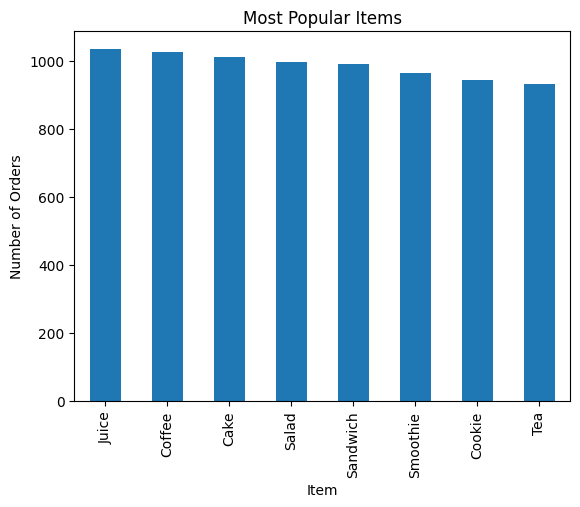

In [ ]:
# plot a countplot to visualize 'Item'
cafe_data['Item'].value_counts().plot(kind='bar')
plt.title('Most Popular Items')
plt.xlabel('Item')
plt.ylabel('Number of Orders')
plt.show()

# juice and coffee are the most popular items

/tmp/ipykernel_3035/757211937.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cafe_data.groupby('Item')['Total Spent'].sum().sort_values().plot(kind='barh')


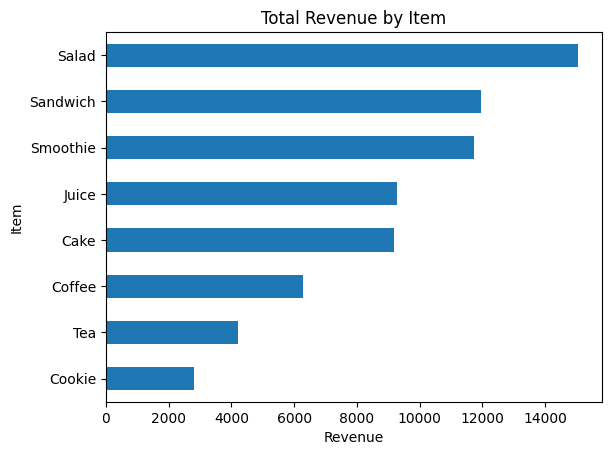

In [ ]:
# plot Revenue by Item
cafe_data.groupby('Item')['Total Spent'].sum().sort_values().plot(kind='barh')
plt.title('Total Revenue by Item')
plt.xlabel('Revenue')
plt.show()

# Salad has the most total revenue

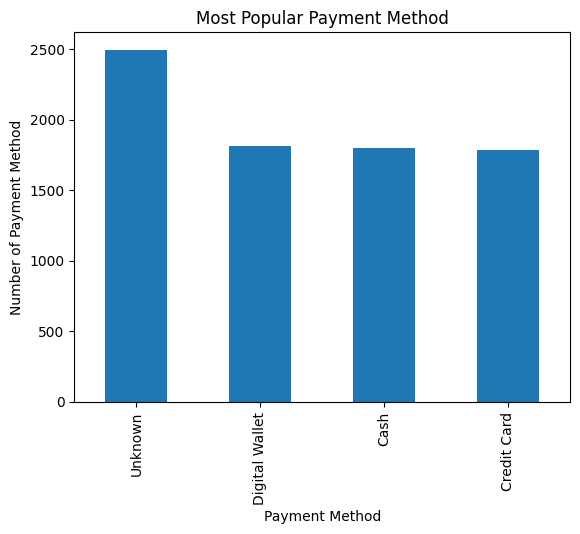

In [ ]:
# Payment method distribution with countplot
cafe_data['Payment Method'].value_counts().plot(kind='bar')
plt.title('Most Popular Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Payment Method')
plt.show()

# While most popular payment method is not known, digital wallet comes next

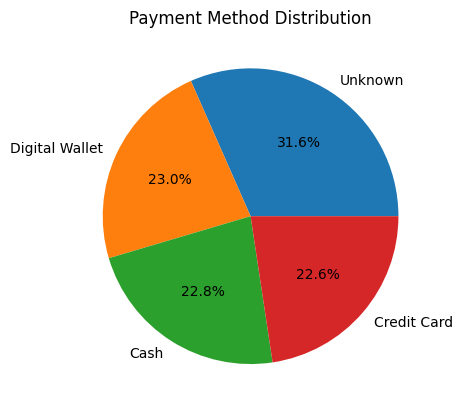

In [ ]:
# Payment method distribution with countplot using a pie chart
cafe_data['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

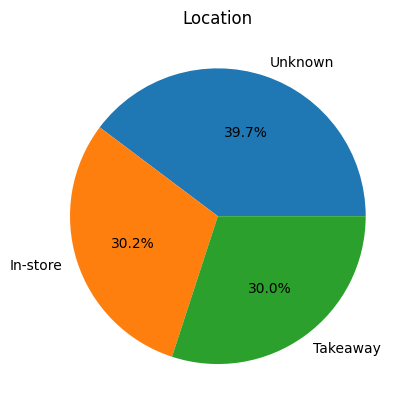

In [ ]:
# Location comparison using a pie chart
cafe_data['Location'].value_counts().plot(kind='pie', autopct= '%1.1f%%')
plt.title('Location')
plt.ylabel('')
plt.show()

# in-store is slightly higher than takeaway

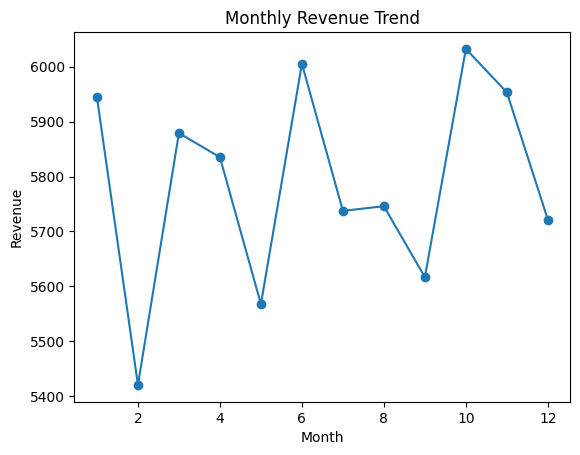

In [ ]:
# Time trend
# we need first to extract date parts
cafe_data['Month'] = cafe_data['Transaction Date'].dt.month

cafe_data.groupby('Month')['Total Spent'].sum().plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

# we see seasonlity in revenues

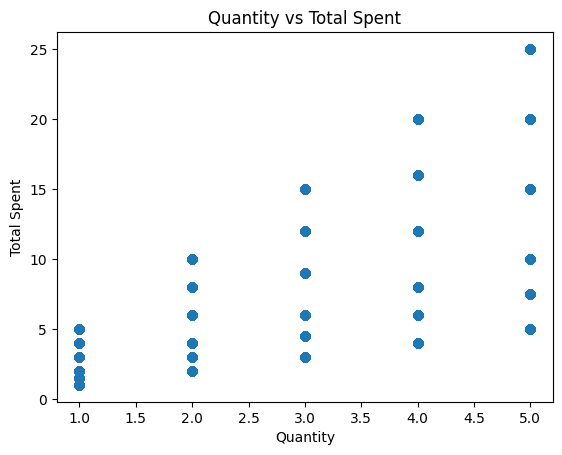

In [ ]:
# Relationship between Quantity vs Total Spent

plt.scatter(cafe_data['Quantity'], cafe_data['Total Spent'])
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

# The visualization shows as quantity increases, so does total spent

<Axes: xlabel='Quantity', ylabel='Total Spent'>

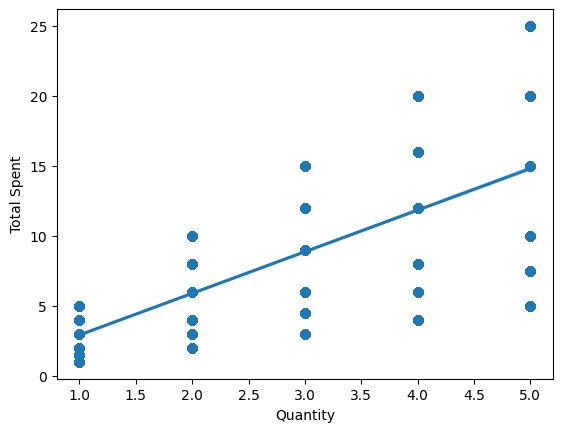

In [ ]:
# we do the same visualization with a regression line
sns.regplot(x='Quantity', y='Total Spent', data=cafe_data)

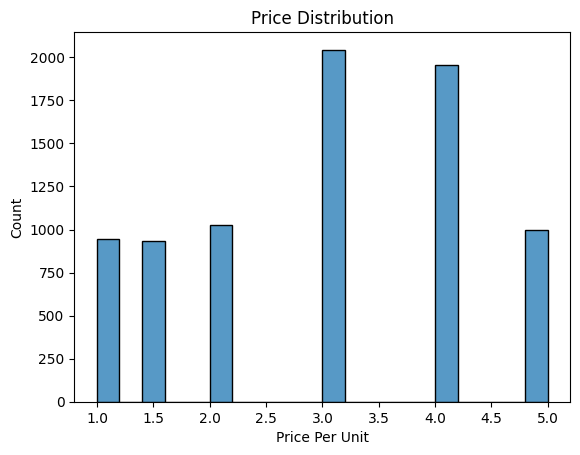

In [ ]:
# Price distribution
sns.histplot(x= 'Price Per Unit', data= cafe_data)
plt.title('Price Distribution')
plt.xlabel('Price Per Unit')
plt.ylabel('Count')
plt.show()